
# **Mathematics and Machine Learning for image analysis**
**COMPUTATIONAL IMAGING LAB (04/06/2025)**


Goals of the tutorial:

1. Basic image processing with numpy, skimage, matplotlib
2. Image denoising: implementing variational regularization methods
3. Image denoising: train a neural network denoiser via pytorch


Luca Ratti, Università di Bologna, luca.ratti5@unibo.it

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# Importing images, basic operations and metrics
from skimage.data import astronaut,shepp_logan_phantom
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.metrics import mean_squared_error, normalized_root_mse, peak_signal_noise_ratio, structural_similarity

# forward models
from skimage.util import random_noise

# Network definition and training
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset,DataLoader

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#np.random.seed(42)

(512, 512, 3)
(512, 512)
[[0.5834349  0.41485922 0.24405843]
 [0.67558824 0.55600667 0.44905294]
 [0.7663349  0.70052431 0.64927608]]


Text(0.5, 1.0, 'Cropped image')

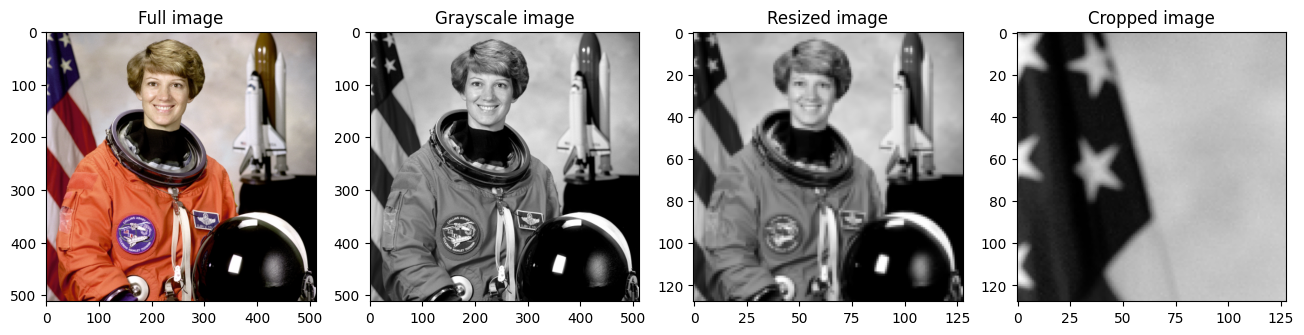

In [ ]:
# Relevant benchmark for imaging problems: Eileen Collins
# https://en.wikipedia.org/wiki/Eileen_Collins

x_ast = astronaut()
x_gray = rgb2gray(x_ast)

print(x_ast.shape)
#print(x_ast[0:3,0:3,0:3])
print(x_gray.shape)
print(x_gray[0:3,0:3])

np_small = 128
x_resize = resize(x_gray, (np_small,np_small), order=0,preserve_range=True,anti_aliasing=True)
pstart_ver = 0
pstart_hor = 0
x_small = x_gray[pstart_ver:pstart_ver+np_small,pstart_hor:pstart_hor+np_small]


fig, axs = plt.subplots(1,4,figsize=(16,4))
axs[0].imshow(x_ast)
axs[0].set_title('Full image')
axs[1].imshow(x_gray, cmap='gray')
axs[1].set_title('Grayscale image')
axs[2].imshow(x_resize, cmap='gray')
axs[2].set_title('Resized image')
axs[3].imshow(x_small, cmap='gray')
axs[3].set_title('Cropped image')

# Task: crop the image to show Eileen Collin's face

# **Noise models**

Random oscillations in the acquisition of a picture.

**Additive noise:**
$$ y = x + \epsilon, \qquad \mathbb{E}[\epsilon]=0, \quad \operatorname{Var}[\epsilon]=\Sigma_ϵ \in \mathbb{R}^{n \times n}$$
(example: Gaussian noise, $ϵ \sim \mathcal{N}(0, \sigma^2 \operatorname{Id})$)

**Poisson noise:** a non-additive, signal dependent, noise - roughly
$$ [y]_{i,j} \sim \frac{1}{\gamma} \mathcal{P}(\gamma [x]_{i,j})$$

**Salt&pepper noise:** a non-additive noise in which some random pixels are set to 0 and some are set to 1

Text(0.5, 1.0, 'Salt and pepper noise \n MSE: 0.007, NRMSE: 0.163 \n PSNR: 21.266, SSIM: 0.640')

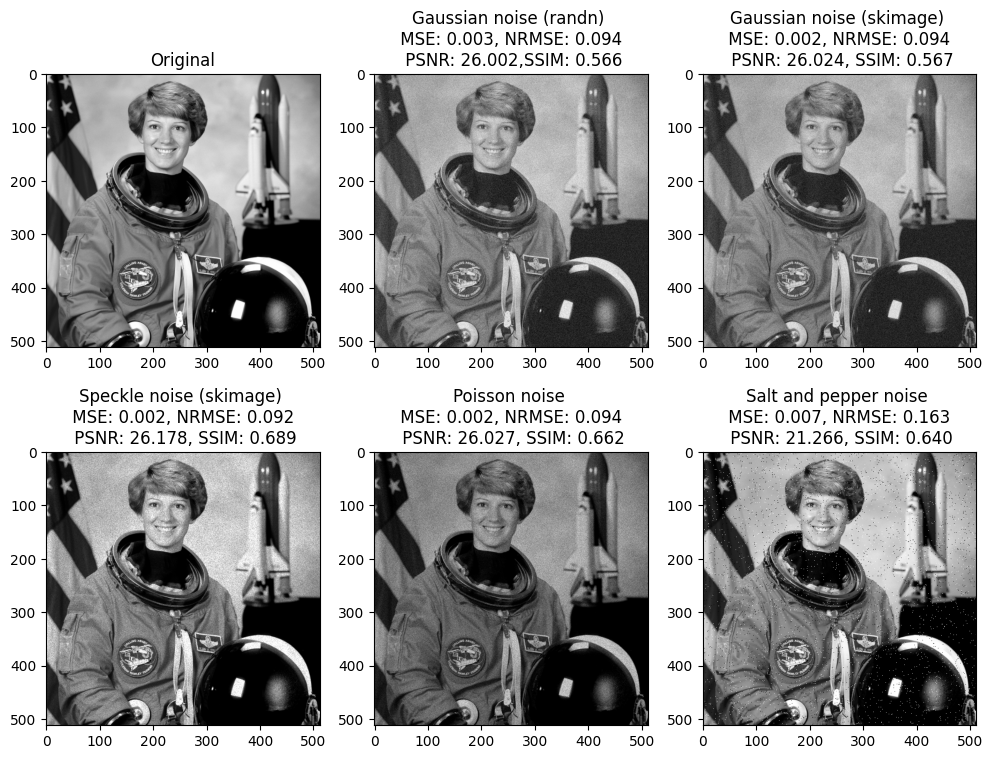

In [ ]:
# Select an image
x = x_gray
n = x.shape[0]

# Additive Gaussian, via numpy
noise_lev = 5e-2 # standard deviation
y_Gauss = x + noise_lev*np.random.randn(n,n)

# Additive Gaussian, via skimage
variance = noise_lev**2
y_Gauss2 = random_noise(x,var=variance,clip=False)

# Poisson noise, via numpy
gain = noise_lev**2/np.mean(x)
y_Poiss = np.random.poisson(x/gain).astype(np.float32)*gain
#y_Poiss = random_noise(x/gain,mode='poisson',clip=False)*gain

# Salt and pepper noise
amount_sp = noise_lev*np.mean(x)
y_sp = random_noise(x, mode='s&p', amount=amount_sp)

# Speckle noise
var_speckle = noise_lev**2/np.mean(x ** 2)
y_spec = random_noise(x, mode='speckle', var=var_speckle)

# Evaluate the intensity of the corruption

# Mean Squared Error
Gauss_MSE  = mean_squared_error(x, y_Gauss)
Gauss2_MSE = mean_squared_error(x, y_Gauss2)
Poiss_MSE  = mean_squared_error(x, y_Poiss)
sp_MSE     = mean_squared_error(x, y_sp)
spec_MSE     = mean_squared_error(x, y_spec)

# Normalized Root MSE
Gauss_NRMSE  = normalized_root_mse(x, y_Gauss)
Gauss2_NRMSE = normalized_root_mse(x, y_Gauss2)
Poiss_NRMSE  = normalized_root_mse(x, y_Poiss)
sp_NRMSE     = normalized_root_mse(x, y_sp)
spec_NRMSE   = normalized_root_mse(x, y_spec)

# PSNR
Gauss_PSNR  = peak_signal_noise_ratio(x, y_Gauss)
Gauss2_PSNR = peak_signal_noise_ratio(x, y_Gauss2)
Poiss_PSNR  = peak_signal_noise_ratio(x, y_Poiss)
sp_PSNR     = peak_signal_noise_ratio(x, y_sp)
spec_PSNR     = peak_signal_noise_ratio(x, y_spec)

# SSIM
Gauss_SSIM  = structural_similarity(x, y_Gauss,data_range=1)
Gauss2_SSIM = structural_similarity(x, y_Gauss2,data_range=1)
Poiss_SSIM  = structural_similarity(x, y_Poiss,data_range=1)
sp_SSIM     = structural_similarity(x, y_sp,data_range=1)
spec_SSIM   = structural_similarity(x, y_spec,data_range=1)


fig, axs = plt.subplots(2,3,figsize=(12,9))
axs[0,0].imshow(x, cmap='gray')
axs[0,0].set_title('Original')
axs[0,1].imshow(y_Gauss, cmap='gray')
axs[0,1].set_title('Gaussian noise (randn) \n MSE: %.3f, NRMSE: %.3f \n PSNR: %.3f,SSIM: %.3f' % (Gauss_MSE, Gauss_NRMSE, Gauss_PSNR,Gauss_SSIM) )
axs[0,2].imshow(y_Gauss2, cmap='gray')
axs[0,2].set_title('Gaussian noise (skimage) \n MSE: %.3f, NRMSE: %.3f \n PSNR: %.3f, SSIM: %.3f'  % (Gauss2_MSE, Gauss2_NRMSE, Gauss2_PSNR, Gauss2_SSIM) )
axs[1,0].imshow(y_spec, cmap='gray')
axs[1,0].set_title('Speckle noise (skimage) \n MSE: %.3f, NRMSE: %.3f \n PSNR: %.3f, SSIM: %.3f'  % (spec_MSE, spec_NRMSE, spec_PSNR, spec_SSIM) )
axs[1,1].imshow(y_Poiss, cmap='gray')
axs[1,1].set_title('Poisson noise \n MSE: %.3f, NRMSE: %.3f \n PSNR: %.3f, SSIM: %.3f'  % (Poiss_MSE, Poiss_NRMSE, Poiss_PSNR, Poiss_SSIM))
axs[1,2].imshow(y_sp, cmap='gray')
axs[1,2].set_title('Salt and pepper noise \n MSE: %.3f, NRMSE: %.3f \n PSNR: %.3f, SSIM: %.3f' % (sp_MSE, sp_NRMSE, sp_PSNR, sp_SSIM))


# TASK: change the noise level

# **Variational denoisers**

**Tikhonov**

Penalizes solutions with large norms:

$$ x_{\lambda} = \arg\min_{x \in \mathbf{R}^n} \left\{ \frac{1}{2}\| Ax - y \|_2^2 + \lambda \| x\|_2^2\right\}$$

The solution can be found via first-order optimality conditions:

$$  A^T(A x_{\lambda} -y) + \lambda x_{\lambda} = 0 \quad ⇒ \quad (A^T A + \lambda \operatorname{Id})x_{\lambda} = A^T y $$

In denoising, $A = \operatorname{I}$, so $x_\lambda = \frac{1}{1+\lambda}y$.

**Lasso**

Promotes the sparsity of the solution
$$ x_{\lambda} = \arg\min_{x \in \mathbf{R}^n} \left\{ \frac{1}{2}\| Ax - y \|^2 + \lambda \| x\|_1\right\}$$

In denoising, the solution is given by $x_\lambda = \operatorname{prox}_{\lambda \|\cdot\|_1}(y) = \operatorname{ST}(y;\lambda)$.


Text(0.5, 1.0, 'Noisy \n MSE: 0.010, PSNR: 20.107')

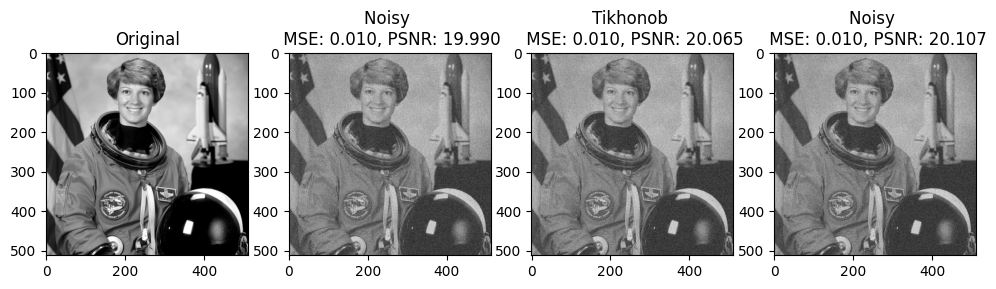

In [ ]:
x = x_gray
n = x.shape[0]

noise_lev = 1e-1 # standard deviation
y = x + noise_lev*np.random.randn(n,n)

lambda_Tikh = 1e-2
x_Tikh = y/(1+lambda_Tikh)

def soft_thresh(x,l):
  return np.multiply(np.sign(x),np.maximum(np.abs(x)-l,np.zeros_like(x)))

lambda_Lasso = 1e-2
x_Lasso = soft_thresh(y,lambda_Lasso)


# Mean Squared Error
Orig_MSE  = mean_squared_error(x, y)
Tikh_MSE  = mean_squared_error(x, x_Tikh)
Lasso_MSE = mean_squared_error(x, x_Lasso)

# Mean Squared Error
Orig_PSNR  = peak_signal_noise_ratio(x, y)
Tikh_PSNR  = peak_signal_noise_ratio(x, x_Tikh)
Lasso_PSNR = peak_signal_noise_ratio(x, x_Lasso)


fig, axs = plt.subplots(1,4,figsize=(12,3))
axs[0].imshow(x, cmap='gray')
axs[0].set_title('Original')
axs[1].imshow(y, cmap='gray')
axs[1].set_title('Noisy \n MSE: %.3f, PSNR: %.3f' % (Orig_MSE, Orig_PSNR))
axs[2].imshow(x_Tikh, cmap='gray')
axs[2].set_title('Tikhonob \n MSE: %.3f, PSNR: %.3f' % (Tikh_MSE, Tikh_PSNR))
axs[3].imshow(x_Lasso, cmap='gray')
axs[3].set_title('Noisy \n MSE: %.3f, PSNR: %.3f' % (Lasso_MSE, Lasso_PSNR))


# **A supervised dataset for image denoising**

We use MNIST, a dataset of images of small size (28x28).
The dataset intended for classification, and presents pairs of images of hand-written digits with labels, the label being the corresponding digit.

We download the dataset, extract the images and create a noisy version of each of them.

Text(0.5, 1.0, 'Sample 3 - noisy')

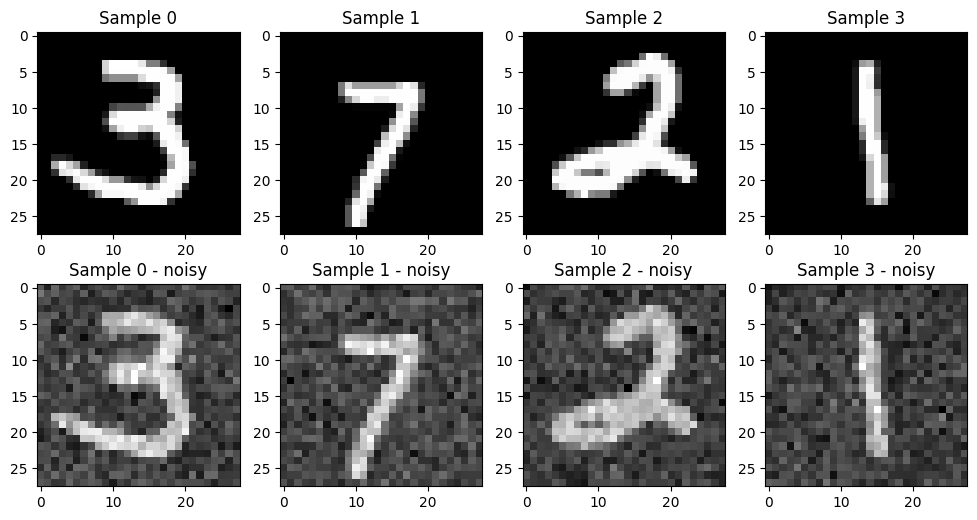

In [ ]:
# Load MNIST dataset
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Load full MNIST training and test sets
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

# Set the size of training and testing datasets
n_train_max = (250 if torch.cuda.is_available() else 50) # number of images used for training
n_test_max = (50 if torch.cuda.is_available() else 10)  # number of images used for testing

# Randomly sample indices
train_indices = np.random.choice(len(mnist_train), size=n_train_max, replace=False)
test_indices  = np.random.choice(len(mnist_test), size=n_test_max, replace=False)

# Extract only the images (discard labels)
train_images = [mnist_train[i][0] for i in train_indices]
test_images  = [mnist_test[i][0] for i in test_indices]

noise_lev = 1.5e-1
noisy_train_images = [mnist_train[i][0]+ torch.randn_like(mnist_train[i][0])*noise_lev for i in train_indices]
noisy_test_images = [mnist_test[i][0]+ torch.randn_like(mnist_test[i][0])*noise_lev for i in test_indices]


# Define custom dataset
class SupervisedDenoisingDataset(Dataset):
    def __init__(self, images,noisy_images):
        self.images = images
        self.noisy_images = noisy_images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.noisy_images[idx]

# Create datasets and loaders
train_dataset = SupervisedDenoisingDataset(train_images,noisy_train_images)
test_dataset  = SupervisedDenoisingDataset(test_images,noisy_test_images)
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
test_loader  = DataLoader(test_dataset , batch_size=5, shuffle=False)

# Visualization
fig, axs = plt.subplots(2,4,figsize=(12,6))
axs[0,0].imshow(test_dataset[0][0].squeeze(), cmap='gray')
axs[0,0].set_title('Sample 0')
axs[0,1].imshow(test_dataset[1][0].squeeze(), cmap='gray')
axs[0,1].set_title('Sample 1')
axs[0,2].imshow(test_dataset[2][0].squeeze(), cmap='gray')
axs[0,2].set_title('Sample 2')
axs[0,3].imshow(test_dataset[3][0].squeeze(), cmap='gray')
axs[0,3].set_title('Sample 3')
axs[1,0].imshow(test_dataset[0][1].squeeze(), cmap='gray')
axs[1,0].set_title('Sample 0 - noisy')
axs[1,1].imshow(test_dataset[1][1].squeeze(), cmap='gray')
axs[1,1].set_title('Sample 1 - noisy')
axs[1,2].imshow(test_dataset[2][1].squeeze(), cmap='gray')
axs[1,2].set_title('Sample 2 - noisy')
axs[1,3].imshow(test_dataset[3][1].squeeze(), cmap='gray')
axs[1,3].set_title('Sample 3 - noisy')

Let us visualize the effect of variational regularization on the MNIST dataset

<ipython-input-4-7043744d7e87>:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.multiply(np.sign(x),np.maximum(np.abs(x)-l,np.zeros_like(x)))


Average MSE of noisy images           : 0.004478
Average MSE of Tikhonov reconstruction: 0.004391
Average MSE of Lasso reconstruction   : 0.007226


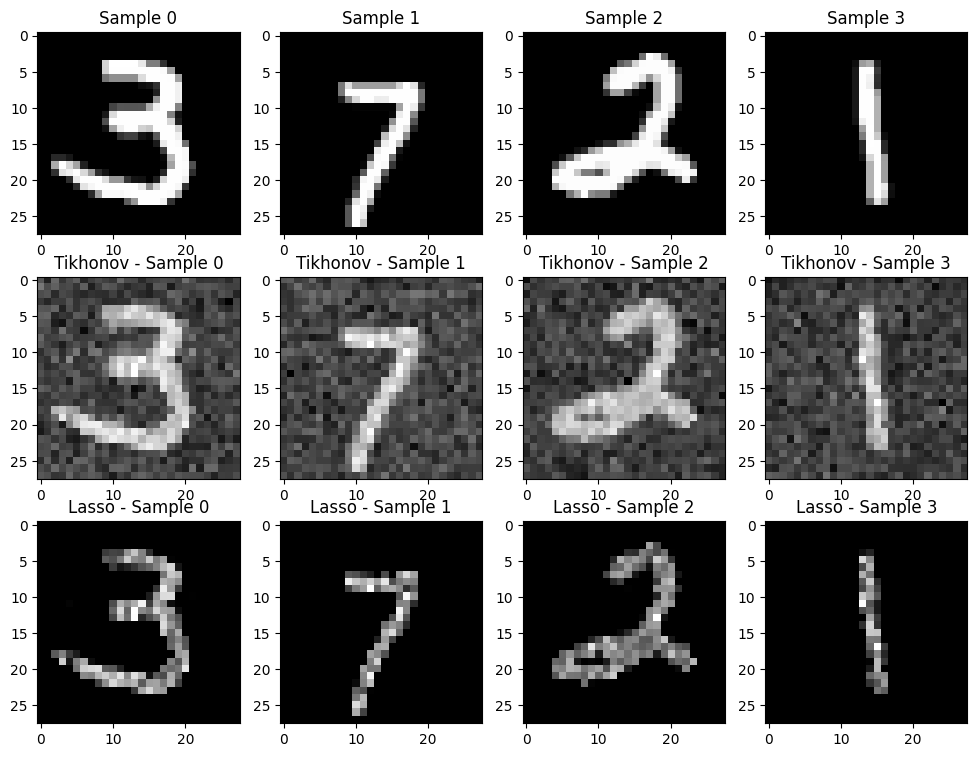

In [ ]:
lambda_Tikh = 1e-2
lambda_Lasso = 2e-1

# Visualize the reconstructions on some digits form the test set
fig, axs = plt.subplots(3,4,figsize=(12,9))
axs[0,0].imshow(test_dataset[0][0].squeeze(), cmap='gray')
axs[0,0].set_title('Sample 0')
axs[0,1].imshow(test_dataset[1][0].squeeze(), cmap='gray')
axs[0,1].set_title('Sample 1')
axs[0,2].imshow(test_dataset[2][0].squeeze(), cmap='gray')
axs[0,2].set_title('Sample 2')
axs[0,3].imshow(test_dataset[3][0].squeeze(), cmap='gray')
axs[0,3].set_title('Sample 3')


tikh0 = test_dataset[0][1].squeeze()/(1+lambda_Tikh)
tikh1 = test_dataset[1][1].squeeze()/(1+lambda_Tikh)
tikh2 = test_dataset[2][1].squeeze()/(1+lambda_Tikh)
tikh3 = test_dataset[3][1].squeeze()/(1+lambda_Tikh)
axs[1,0].imshow(tikh0, cmap='gray')
axs[1,0].set_title('Tikhonov - Sample 0')
axs[1,1].imshow(tikh1, cmap='gray')
axs[1,1].set_title('Tikhonov - Sample 1')
axs[1,2].imshow(tikh2, cmap='gray')
axs[1,2].set_title('Tikhonov - Sample 2')
axs[1,3].imshow(tikh3, cmap='gray')
axs[1,3].set_title('Tikhonov - Sample 3')

lasso0 = soft_thresh(test_dataset[0][1].squeeze(),lambda_Lasso)
lasso1 = soft_thresh(test_dataset[1][1].squeeze(),lambda_Lasso)
lasso2 = soft_thresh(test_dataset[2][1].squeeze(),lambda_Lasso)
lasso3 = soft_thresh(test_dataset[3][1].squeeze(),lambda_Lasso)
axs[2,0].imshow(lasso0, cmap='gray')
axs[2,0].set_title('Lasso - Sample 0')
axs[2,1].imshow(lasso1, cmap='gray')
axs[2,1].set_title('Lasso - Sample 1')
axs[2,2].imshow(lasso2, cmap='gray')
axs[2,2].set_title('Lasso - Sample 2')
axs[2,3].imshow(lasso3, cmap='gray')
axs[2,3].set_title('Lasso - Sample 3')


# Compute the average MSE on the test set
Original_MSE = 0.0
Tikhonov_MSE = 0.0
Lasso_MSE    = 0.0

# Loop on the test set and sum the MSE
for clean, noisy in test_loader:
  clean = clean.to('cpu').numpy()
  noisy = noisy.to('cpu').numpy()
  x_Tikh = noisy/(1+lambda_Tikh)
  x_Lasso = soft_thresh(noisy,lambda_Lasso)
  Original_MSE += mean_squared_error(noisy, clean)
  Tikhonov_MSE += mean_squared_error(x_Tikh, clean)
  Lasso_MSE    += mean_squared_error(x_Lasso, clean)

# Compute averages
Original_MSE /= n_test_max
Tikhonov_MSE /= n_test_max
Lasso_MSE /= n_test_max

print(f"Average MSE of noisy images           : {Original_MSE:.6f}")
print(f"Average MSE of Tikhonov reconstruction: {Tikhonov_MSE:.6f}")
print(f"Average MSE of Lasso reconstruction   : {Lasso_MSE:.6f}")


# TASK: explore the effect of different values of lambda. Why is Lasso working better?
# TASK*: find the best value of lambda as the one that performs best on the training set

# **A neural network denoiser**
- We define a UNet architecture for image denoising
- We train it on the training dataset
- We verify its effectiveness on the test dataset

In [ ]:
class UNetMini(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU())

        # Decoder
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())

        # Final output
        self.out_conv = nn.Conv2d(32, 1, 1)

        # Apply weight initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)     # [B, 32, 28, 28]
        p1 = self.pool(e1)    # [B, 32, 14, 14]
        e2 = self.enc2(p1)    # [B, 64, 14, 14]
        p2 = self.pool(e2)    # [B, 64, 7, 7]
        b = self.bottleneck(p2)  # [B, 128, 7, 7]
        u1 = self.up1(b)      # [B, 64, 14, 14]
        u1 = torch.cat([u1, e2], dim=1)  # skip connection
        d1 = self.dec1(u1)    # [B, 64, 14, 14]
        u2 = self.up2(d1)     # [B, 32, 28, 28]
        u2 = torch.cat([u2, e1], dim=1)
        d2 = self.dec2(u2)    # [B, 32, 28, 28]
        return torch.sigmoid(self.out_conv(d2))  # output in [0,1]

In [ ]:
# Training

# Tunable parameters
num_epochs = 20
learning_rate=1e-3

# Model, loss, optimizer
model = UNetMini().to('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
device = next(model.parameters()).device
model.train()

# Training loop
for epoch in range(num_epochs):

    total_loss = 0
    for clean, noisy in train_loader:
        clean, noisy = clean.to(device), noisy.to(device)
        output = model(noisy)
        loss = criterion(output, clean)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.1107
Epoch 2, Loss: 0.0172
Epoch 3, Loss: 0.0081
Epoch 4, Loss: 0.0051
Epoch 5, Loss: 0.0039
Epoch 6, Loss: 0.0033
Epoch 7, Loss: 0.0029
Epoch 8, Loss: 0.0027
Epoch 9, Loss: 0.0024
Epoch 10, Loss: 0.0023
Epoch 11, Loss: 0.0022
Epoch 12, Loss: 0.0021
Epoch 13, Loss: 0.0021
Epoch 14, Loss: 0.0020
Epoch 15, Loss: 0.0019
Epoch 16, Loss: 0.0018
Epoch 17, Loss: 0.0017
Epoch 18, Loss: 0.0017
Epoch 19, Loss: 0.0017
Epoch 20, Loss: 0.0016


Average MSE of noisy images - test set   : 0.004478
Average MSE of denoised images - test set: 0.000493


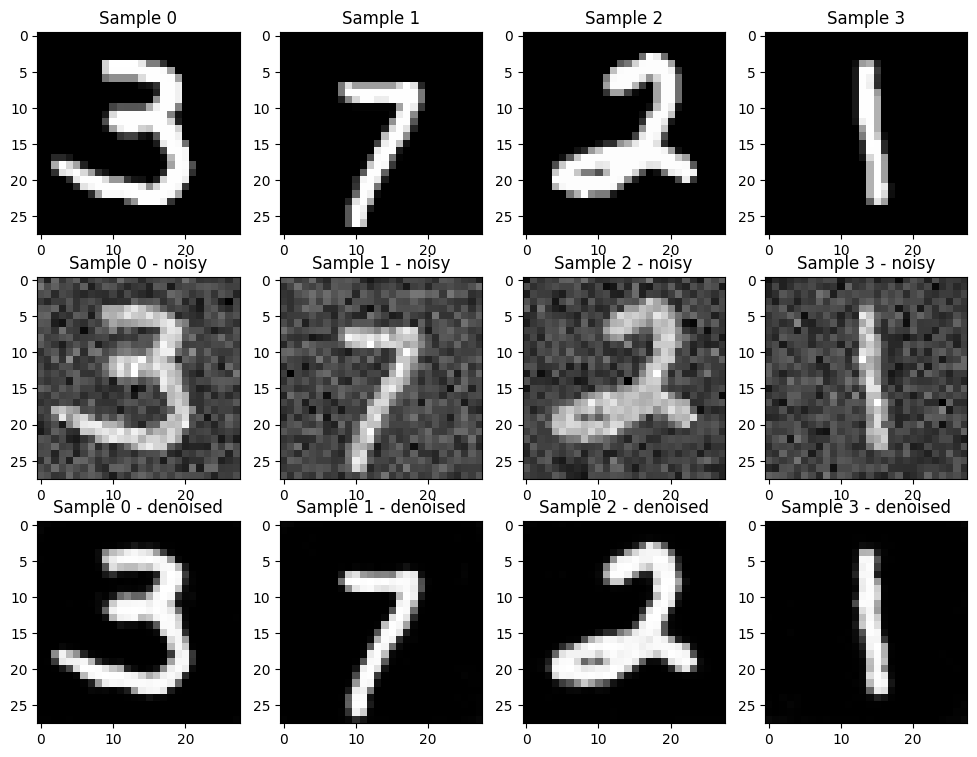

In [ ]:
# Test
model.eval()

# Visualize some reconstructions
with torch.no_grad():
  denoised0 = model(test_dataset[0][1].unsqueeze(0).to(device)).cpu().squeeze()
  denoised1 = model(test_dataset[1][1].unsqueeze(0).to(device)).cpu().squeeze()
  denoised2 = model(test_dataset[2][1].unsqueeze(0).to(device)).cpu().squeeze()
  denoised3 = model(test_dataset[3][1].unsqueeze(0).to(device)).cpu().squeeze()
fig, axs = plt.subplots(3,4,figsize=(12,9))
axs[0,0].imshow(test_dataset[0][0].squeeze(), cmap='gray')
axs[0,0].set_title('Sample 0')
axs[0,1].imshow(test_dataset[1][0].squeeze(), cmap='gray')
axs[0,1].set_title('Sample 1')
axs[0,2].imshow(test_dataset[2][0].squeeze(), cmap='gray')
axs[0,2].set_title('Sample 2')
axs[0,3].imshow(test_dataset[3][0].squeeze(), cmap='gray')
axs[0,3].set_title('Sample 3')
axs[1,0].imshow(test_dataset[0][1].squeeze(), cmap='gray')
axs[1,0].set_title('Sample 0 - noisy')
axs[1,1].imshow(test_dataset[1][1].squeeze(), cmap='gray')
axs[1,1].set_title('Sample 1 - noisy')
axs[1,2].imshow(test_dataset[2][1].squeeze(), cmap='gray')
axs[1,2].set_title('Sample 2 - noisy')
axs[1,3].imshow(test_dataset[3][1].squeeze(), cmap='gray')
axs[1,3].set_title('Sample 3 - noisy')

axs[2,0].imshow(denoised0, cmap='gray')
axs[2,0].set_title('Sample 0 - denoised')
axs[2,1].imshow(denoised1.squeeze(), cmap='gray')
axs[2,1].set_title('Sample 1 - denoised')
axs[2,2].imshow(denoised2.squeeze(), cmap='gray')
axs[2,2].set_title('Sample 2 - denoised')
axs[2,3].imshow(denoised3.squeeze(), cmap='gray')
axs[2,3].set_title('Sample 3 - denoised')


# Loop on the test set and
Original_MSE = 0.0
NN_MSE = 0.0
with torch.no_grad():
  for clean, noisy in test_loader:
    clean = clean.to(device)
    noisy = noisy.to(device)
    output = model(noisy)
    Original_MSE += F.mse_loss(noisy, clean, reduction='mean').item()
    NN_MSE += F.mse_loss(output, clean, reduction='mean').item()

    # #Equivalent MSE computation with skimage
    # clean = clean.numpy()
    # noisy = noisy.numpy()
    # output = output.numpy()
    # Original_MSE += mean_squared_error(noisy, clean)
    # NN_MSE += mean_squared_error(output, clean)

# Compute averages
Original_MSE /= n_test_max
NN_MSE /= n_test_max

print(f"Average MSE of noisy images - test set   : {Original_MSE:.6f}")
print(f"Average MSE of denoised images - test set: {NN_MSE:.6f}")